<a href="https://colab.research.google.com/github/Text-Machine/mask-predict/blob/main/chr-paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> </a>

# CHR Paper notebook

This notebook aims to reproduce all figures and tables that inform the analysis of the CHR paper.

In [ ]:
!git clone https://github.com/Text-Machine/mask-predict.git

In [ ]:
%cd mask-predict

In [ ]:
!pip install -q -e .

In [2]:
import pandas as pd
import json
from tqdm import tqdm
from explain import *
from pathlib import Path
from collections import Counter
import seaborn as sns

In [ ]:
%cd /content

In [ ]:
!gdown 125wfZ1P9MfFZ19XS2SCfallsnoNhLCUf

In [ ]:
!unzip -o "chr-data.zip"

In [4]:
collection,genre_suffix = 'blb',''
if collection == 'blb':
  genre_suffix = '_with_genre'

TargetMaskedToken = 'machine' # the token to be masked in the target sentence
try:
  import google.colab
  originalFolder = '.' # change to '.' when working in colab
  dataPath = '.' # change to '.' when working in colab 
  processedFolder = '.' # change '.' when working in colab
except:
  originalFolder = 'masking_data' # change to '.' when working in colab
  dataPath = 'input_data' # change to '.' when working in colab 
  processedFolder = 'gradient_data' # change '.' when working in colab

predCol = "pred_bert_1760_1900"
resultType = 'pred_kw_filtered' # pred | pred_kw_filter

print(f"This analysis focuses on '{TargetMaskedToken}'.")

This analysis focuses on 'machine'.


We are loading the data frame with deduplicated sentences.

In [5]:
df_sent_all = pd.read_csv(f'{originalFolder}/{collection}_{TargetMaskedToken}_clusters{genre_suffix}_deduplicated.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent_all.shape[0]} unique sentences for the target token {TargetMaskedToken} in the {collection} collection.')


We have 77907 unique sentences for the target token machine in the blb collection.


In [6]:
# load the original sentences with the predicted tokens
df_sent = pd.read_csv(f'{dataPath}/{collection}_{TargetMaskedToken}{genre_suffix}_{resultType}.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent.shape[0]} sentences that produced human predictions for the target token {TargetMaskedToken} in the {collection} collection.')
df_ig = pd.read_csv(f'{processedFolder}/results_{collection}_{TargetMaskedToken}_{resultType}_processed.csv', index_col=0 )
print(f'We have {df_ig.shape[0]} explanations for the target token {TargetMaskedToken} in the {collection} collection.')


We have 19003 sentences that produced human predictions for the target token machine in the blb collection.
We have 2173047 explanations for the target token machine in the blb collection.


Here we load the words that we selected as human prediction, i.e. these are words predicted by BLERT possible referring to human fillers for the masked machine token.

In [7]:
with open(f'{dataPath}/250_freq_pred_KB_edit.txt') as f:
    human_words = f.read().splitlines()

print(human_words[:10])

['man', 'men', 'woman', 'child', 'people', 'person', 'hands', 'boy', 'girl', 'children']


We create a new column where filter the prediction, only retaining the human words.

In [8]:
for colName in ['pred_bert_contemporary', 'pred_bert_1760_1900']:
    df_sent[f'{colName}_human'] = df_sent[colName].apply(
        lambda x: {w:s for w, s in dict(eval(x)).items() if w in human_words})


We look at results by decade, therefore adding decade column to the data frames

In [9]:
df_sent_all['decade'] = df_sent_all['date'].apply(lambda x: int(x/10)*10)
df_sent['decade'] = df_sent['date'].apply(lambda x: int(x/10)*10)

### Analysis: Distribution of predictions

BLERT is not always equally convinced of it's predictions. Below we plot the distribution of it confidence scores for the human words it predicted instead of machine. These are the probabilities that a word fits the given context in the position of the masked token. We see that 

Distribution of the human prediction scores for the target token '{TargetMaskedToken}' in the {collection} collection.


<Axes: >

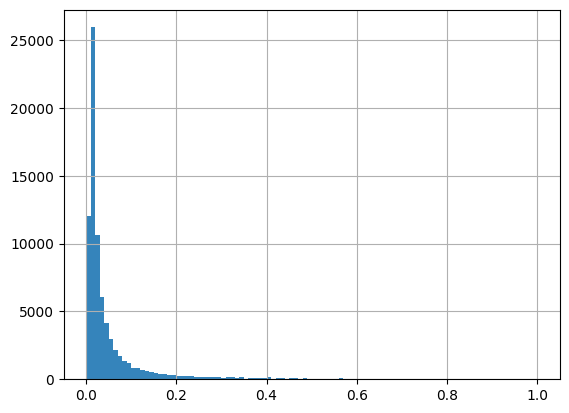

In [10]:
import itertools
scores_human = list(itertools.chain.from_iterable(df_sent['pred_bert_1760_1900_human'].apply(lambda x: list(x.values()))))
scores_all = list(itertools.chain.from_iterable(df_sent['pred_bert_1760_1900'].apply(lambda x: list(dict(eval(x)).values()))))

print("Distribution of the human prediction scores for the target token '{TargetMaskedToken}' in the {collection} collection.")
#pd.Series(scores_human).plot(kind='density')
pd.Series(scores_human).hist(bins=100, alpha=0.9, label='human predictions')
#pd.Series(scores_all).plot(kind='density', alpha=0.5)


### Analysis: timeline for all predictions

Below we plot the number of unique sentences containing 'human' predictions for masked machine tokens. We plot by decade, for all the human predictions, higher than a set confidence threshold. 

While maybe not drastically, we observe a small rise in the relative number of 'atypical' sentences or 'atypical' language use.

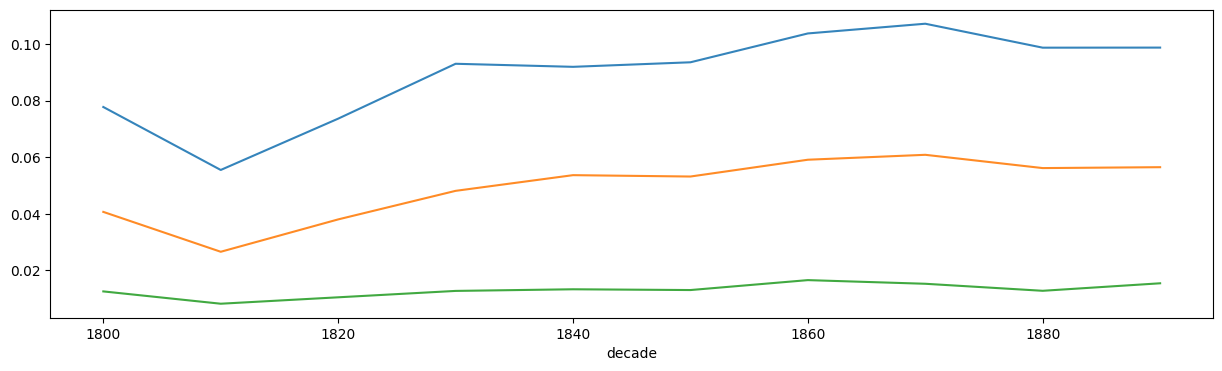

In [11]:
time_unit = 'decade' # change to 'date' for yearly analysis
thresholds = [0.1, 0.2, 0.5]
for threshold in thresholds:
    df_sent_filtered = df_sent[df_sent['pred_bert_1760_1900_human'].apply(lambda x: max(list(x.values())+[.0]) > threshold)]
    (df_sent_filtered.groupby(time_unit).size()/df_sent_all.groupby(time_unit).size()).loc[1800:1899].plot(alpha=0.9,
                                                                                                            title=f'', 
                                                                                                            xlabel=f'{time_unit}',
                                                                                                            figsize=(15, 4))


### Analysis: timeline for a selected thema

By changing the `wordList` variable below, we can plot timelines for specific subset or theme of predictions. 

The children theme shows a pronounced upward trend. This could be one of the subquestions we address in the paper: how and why the increasing confusion of child and machine?

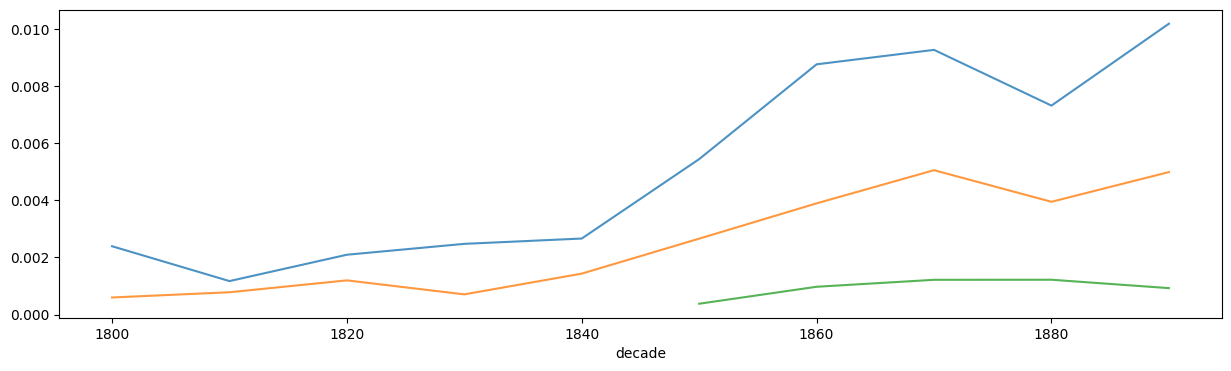

In [12]:
time_unit = 'decade' # change to 'date' for yearly analysis
thresholds = [ 0.1, 0.2, 0.5] # compare the results for different thresholds to see how the results change based on the confidence in the predictions
wordList = ['child','children', 'boy','boys','girl','girls']  # change these words to analyze a different theme
for threshold in thresholds:
    df_sent_filtered = df_sent[df_sent[f'{colName}_human'].apply(
        lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold
                )
            ]
    (df_sent_filtered.groupby(time_unit).size() / df_sent_all.groupby(time_unit).size()).loc[1800:1899].plot(alpha=0.8, 
                                                                                                             title=f'',
                                                                                                               xlabel=f'{time_unit}',
                                                                                                               figsize=(15, 4))


### Analysis: results by genre

The results hold when splitting the data by genre. Upward trend appears in both fiction and non-fiction but, more articulate in the form}er.

<Axes: xlabel='decade', ylabel='0'>

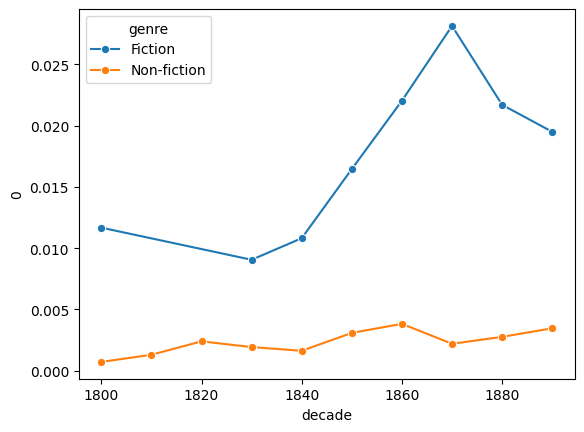

In [13]:

time_unit = 'decade' # change to 'date' for yearly analysis
threshold = 0.1 # use higher thresholds for more conservative analysis, i.e. only sentences with a high probability of the tokens in wordList being predicted are included in the analysis
wordList = ['child','children', 'boy','boys','girl','girls'] # change these words to analyze a different theme

df_sent_filtered = df_sent[df_sent['pred_bert_1760_1900_human'].apply(lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold)]
plot_df = df_sent_filtered.groupby([time_unit, 'genre']).size() / df_sent_all.groupby([time_unit, 'genre']).size()
plot_df_rel = (df_sent_filtered.groupby([time_unit, 'genre']).size() / df_sent_all.groupby([time_unit, 'genre']).size()).reset_index()
sns.lineplot(data=plot_df_rel, x=time_unit, y=0, hue='genre', marker='o')

### Analysis: Distribution of prediction

Which human words does BLERT predict instead of ''machine''? And why? 

We refined the analysis below by allowing to refine the threshold, i.e. to focus only on "confident" predictions etc.

In [14]:

thresholds = 0.1 # change this threshold to see how the results change based on the confidence in the predictions


In [15]:
df_sent_filtered = df_sent[df_sent[f'{colName}_human'].apply(lambda x: max(list(x.values())+[.0]) > threshold)]
preds = Counter([w for l in df_sent_filtered[f'{colName}'].values for w,s in eval(l) if (w in human_words) & (s > threshold) ])

<Axes: title={'center': 'Top 100 predicted tokens for the target token machine.'}, xlabel='Predicted token', ylabel='Count'>

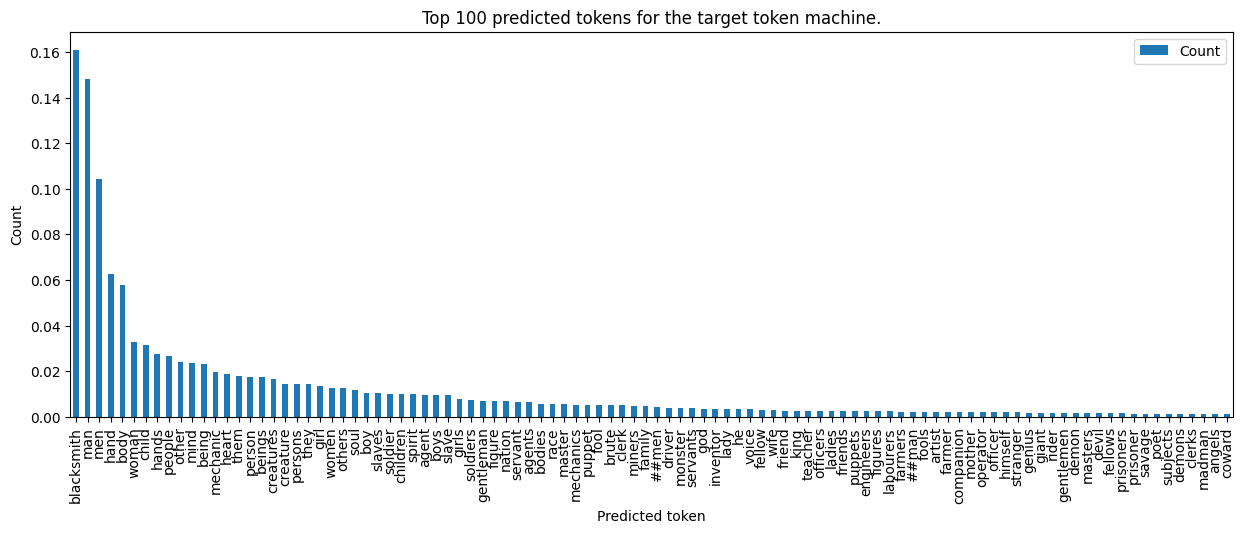

In [16]:
pd.DataFrame([(w, c/len(df_sent_filtered)) for w, c in preds.most_common(100)]
             ).rename(columns={0: 'Predicted token', 1: 'Count'}
                      ).set_index('Predicted token'
                                  ).plot(kind='bar', title=f'Top 100 predicted tokens for the target token {TargetMaskedToken}.', 
                                         ylabel='Count', xlabel='Predicted token', figsize=(15,5))

### Analysis: explainability

Which words drive the predictions, and especially, how to interpet this increasing "confusion" or children with machines? What does it tell us about changes in the discourse about machines.

What we compute is not just how words contribute to the prediction, this tells us often more about what type of sentences are included in our data. We look at which words explain the difference between machine and human words, i.e. which words drive the prediction towards 'human' and away from 'machine'.

More technically, for each word in the sentence we compute pairwise differences between ''machine'' and ''human'' predictions (for the masked token) for each token in the sentence.

In [17]:
# Create row order within each id and Target
df_ig["row_idx"] = df_ig.groupby(["id", "Target"]).cumcount()

# Extract machine/machines scores
machine_scores = (
    df_ig[df_ig["Target"].isin(["machine", "machines"])]
    [["id", "row_idx", "Score_normalized"]]
    .rename(columns={"Score_normalized": "machine_score"})
)

# Match each row with the corresponding machine row
df_ig = df_ig.merge(
    machine_scores,
    on=["id", "row_idx"],
    how="left"
)

# Subtract
df_ig["diff"] = df_ig["Score_normalized"] - df_ig["machine_score"]

# Optional: remove helper column
df_ig.drop(columns=["row_idx", "machine_score"], inplace=True)

In [18]:
df_ig[(df_ig['id'] == 11)].Target.unique()

<ArrowStringArray>
['girl', 'machine']
Length: 2, dtype: str

In [19]:
df_ig[(df_ig['id'] == 11) & (df_ig['Target'].isin(['machine', 'machines']))][['Target', 'Score_normalized', 'diff']].head(3)

,Target,Score_normalized,diff
1474,machine,0.049453,0.0
1475,machine,0.038349,0.0
1476,machine,0.028908,0.0


In [20]:
df_ig[(df_ig['id'] == 11) & (df_ig['Target'].isin(['girl']))][['Target', 'Score_normalized', 'diff']].head(3)

,Target,Score_normalized,diff
1454,girl,0.018882,-0.030571
1455,girl,0.030576,-0.007773
1456,girl,0.033602,0.004694


## Analysis: Explanation scores across all human word predictions

Below is a general analysis, highlighting which context words explain the drifting aways of explanations from the machine.

The threshold, again, regulates, the confidence.

The `df_result` dataframe shows the words that exhibit the highest difference between machine and human words. Below we provide tools for analysing these words, and the sentences, in which they appear, in more depth.

In [21]:
threshold = 0.25


targetTokens = ['machine','machines'] # we look at the predictions for all the non machine words
df_comparisonConcept = df_ig[
    (~df_ig['Target'].isin(targetTokens)) & # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
    (df_ig['Target_score'].between(threshold, 1.0))
                ].groupby('Token').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_diff=('diff', 'mean'), avg_score=('Score_normalized', 'mean')
                    ).reset_index()


In [22]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 20
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_diff', ascending=False)
df_result.head(10)

,Token,count,identifiers,avg_diff,avg_score
6531,human,245,"{8708, 6661, 4614, 6662, 9223, 15365, 13322, 1...",0.018612,0.037350
5207,fellow,23,"{4864, 6664, 10380, 9495, 14748, 1695, 14626, ...",0.011999,0.018966
1000,animal,33,"{5638, 12555, 5261, 4495, 4762, 17949, 418, 12...",0.010887,0.037803
1003,animated,30,"{17544, 2571, 1936, 15250, 17685, 9370, 13467,...",0.010837,0.017095
5817,girls,23,"{18561, 18562, 15006, 18337, 5666, 12070, 4263...",0.010800,0.023239
13693,various,40,"{13313, 16899, 4487, 11528, 6538, 6796, 16141,...",0.009001,0.015110
10039,printed,20,"{16257, 13443, 261, 16784, 6294, 6167, 12952, ...",0.008363,0.019711
12271,stood,27,"{16257, 6412, 9621, 18326, 11033, 9628, 15517,...",0.007890,0.010298
1937,bodies,23,"{16135, 1299, 5783, 12073, 4522, 4913, 10929, ...",0.007619,0.029765
10241,pulse,60,"{4352, 17536, 6787, 16646, 9223, 16917, 278, 3...",0.007309,0.004828


## Analysis: Explanation scores for a specific theme


The code below, repeats the contextual analyis, but focussing on specific theme, defined by the `comparisonTokens` variable. Here we highlight which context words explain the drifting aways of explanations from the machine, with regard to a specific theme.

The `threshold`  regulates, the confidence.

`comarisonTokens` defines a set of words which we compare against machine predictions.

The `df_result` dataframe shows the words that exhibit the highest difference between machine and human words. Below we provide tools for analysing these words, and the sentences, in which they appear, in more depth.

In [23]:


comparisonTokens = ['child','children', 'boy','boys','girl','girls']

df_comparisonConcept = df_ig[
    (df_ig['Target'].isin(comparisonTokens)) & \
    (df_ig['Target_score'].between(0.1, 1.0)) # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
                ].groupby('Token').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_diff=('diff', 'mean'), avg_score=('Score_normalized', 'mean')
                    ).reset_index()


In [24]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 20
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_diff', ascending=False)
df_result.head(10)

,Token,count,identifiers,avg_diff,avg_score
1637,girls,33,"{18561, 18562, 663, 18337, 4263, 15145, 16687,...",0.014579,0.026308
557,boys,24,"{4161, 9051, 11107, 13156, 4997, 14680, 4263, ...",0.009306,0.027787
3940,two,24,"{12160, 2, 16780, 15898, 13224, 17449, 4652, 3...",0.006471,0.012770
10,.,779,"{2, 6, 28, 18462, 10271, 18465, 18466, 6184, 2...",0.004541,0.007323
2191,little,62,"{18692, 5385, 10391, 14103, 5275, 11808, 18465...",0.004172,0.015105
449,been,68,"{10369, 17921, 15491, 5764, 13704, 13705, 1754...",0.003428,0.004522
3437,small,20,"{12568, 15075, 1317, 6, 15558, 15787, 8781, 60...",0.003271,0.013463
556,boy,25,"{6, 5385, 3085, 16795, 7836, 5541, 12201, 1450...",0.002811,0.018611
731,children,28,"{774, 4999, 13704, 15898, 2203, 295, 1320, 151...",0.002591,0.016153
613,by,148,"{3072, 11267, 4628, 2583, 15898, 7717, 2090, 1...",0.002271,0.004472


In [25]:
#df_result.avg_score.plot(kind='hist', bins=100, title=f'Histogram of average scores for tokens predictive of the contrastive concept.', xlabel='Average score', ylabel='Count')

# Analysis: Zooming in on sentences based on context words

You can zoom in a sentences with using the predictive context words. Change the `id` variable below with one of the index numbers of the`df_result` dataframe.

The sentence are ranked, with examples where the context word obtains the highest scores, first.

You can change the following variable:

- `id` selected from the `df_result` dataframe
- `sort_value` how do sort the sentences, i.e. where the impact of the target word is thelargest ('Score_normalized') or makes the biggest difference ('diff')

In [26]:
pd.set_option('display.max_colwidth', 200)

In [27]:
id = 1637
sort_value = 'diff' #'Score_normalized' | 'diff'


identifiers_ranked = df_ig.loc[df_ig['id'].isin(list(df_result.loc[id].identifiers)) \
                             & (df_ig['Token']==df_result.loc[id].Token) \
                             & df_ig['Target'].isin(comparisonTokens)
                             
                             ].sort_values(by=sort_value, ascending=False)['id'].unique()
sentences_ranked = df_sent.iloc[list(identifiers_ranked)].head(20)
sentences_ranked.currentSentence

11509                                              From this small beginning he has continued to in crease his machinery, till he has thirty five machines, and in the busy season he employs twenty five girls.
15200                                                                   " Ten seams of equal length were prepared for sewing, of which five were laid by the machine and the other five were given to the girls.
8147                                                                       The machines are tended by Mestiza girls, who are very neat at their work, going about quietly and without even singing or whistling.
18337                                                                        After the leather has been cut, it is sent into the sewing room, where sixty girls, and a similar number of machines, are employed.
18562    After this the girls were taken down some stairs into a long room where large machines were working on wheels and straps; a great length of the very finest

In [28]:
# Optional: save and expeort sentences
name = 'child'
outPath = Path('sentences')
outPath.mkdir(exist_ok=True)
sentences_ranked.to_csv(outPath / f'{name}_sentences.csv', index=False)

In [29]:
modelName = "Livingwithmachines/bert_1760_1900"
explainer = MaskedLMExplainer(model_name=modelName, device=pick_device())

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: Livingwithmachines/bert_1760_1900
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Analysis: Inspect IG for one sentence

In [30]:
idx = 11509
target_token = 'predicted' # 'actual' | 'predicted'

sentence = df_sent.iloc[idx].maskedSentence

if target_token == 'actual':
    target_token = df_sent.iloc[idx].targetExpression
elif target_token == 'predicted':
    target_token =  [w for w, v in sorted(
       df_sent.iloc[idx].pred_bert_contemporary_human.items(), key=lambda x: x[1], reverse=True)
                     if w in wordList][0]
print(target_token)

boys


In [31]:

highlight_context_tokens(explainer, sentence, target=target_token, word_agg="mean")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_8d5960092fc4432699ebb83554ff7c92">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>boys</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'0.043786\' style=\'background:rgba(30, 136, 229, 0.136); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>from</span> <span class=\'tok\' data-score=\'0.001377\' style=\'background:rgba(30, 136, 229, 0.101); padding:2px 4px; margin

## Inspect sentences based on Context and Predicted token

In [32]:
predictedToken = 'men'
contextToken = 'animal'
sort_value = 'diff' #'Score_normalized' | 'diff'

ids = df_ig[(df_ig['Token'].str.lower() == contextToken) & (df_ig['Target'].str.lower() == predictedToken)
                    ].sort_values(sort_value,ascending=False).id.values

In [33]:
idx = 4495
wordList = human_words
sentence = df_sent.iloc[idx].maskedSentence
targets = list(set(df_ig[df_ig['id'] == idx].Target.unique()).intersection(set(wordList)))
target_expression = df_sent.iloc[idx].targetExpression

In [34]:
print(f"Sentence: {sentence}")
print(f"Targets: {targets}")
print(f"Targets: {target_expression}")

Sentence: It has done much to convert these he Avers of Avood and drawers of Avater from reasoning creatures into animal [MASK] .
Targets: ['beings', 'creatures', 'men']
Targets: machines


In [35]:
#target =targets[0]

In [36]:

highlight_context_tokens(explainer, sentence, target=predictedToken, word_agg="mean")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_dc2343fa44cc480fae695223b851374f">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>men</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'0.142190\' style=\'background:rgba(30, 136, 229, 0.258); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>it</span> <span class=\'tok\' data-score=\'0.104104\' style=\'background:rgba(30, 136, 229, 0.216); padding:2px 4px; margin:1p

# Notebook still under construction here, please ignore or run at your own risk! :-)

## Historical Experiments

In [37]:
df_ig_merged = df_ig.merge(df_sent[['decade','date']], left_on='id',right_index=True, how='left')
df_ig.shape, df_ig_merged.shape

((2173047, 12), (2173047, 14))

<Axes: title={'center': 'Average diff in scores for tokens predictive of the contrastive concept over time.'}, xlabel='decade', ylabel='Average difference in scores'>

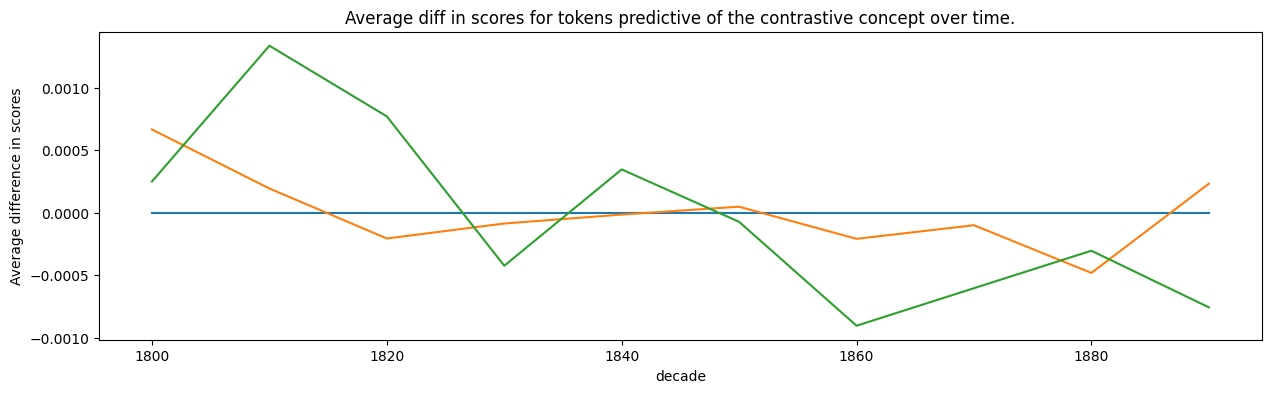

In [48]:
sentence_length = 20
min_confidence = .1
column_name = 'diff' # Score_normalized | diff

df_ig_merged[(df_ig_merged['Target'].isin(['machine','machines'])) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'] > sentence_length)
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot(title=f'Average {column_name} in scores for tokens predictive of the contrastive concept over time.', xlabel='Decade', ylabel='Average difference in scores', figsize=(15, 4))

df_ig_merged[(~df_ig_merged['Target'].isin(['machine','machines'])) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'] > sentence_length)
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot()

df_ig_merged[(df_ig_merged['Target'].isin(comparisonTokens)) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'] > sentence_length)
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot()

In [ ]:
df_ig_merged.columns

In [ ]:
df_ig_merged.groupby(['decade'])['Sentence_length'].mean().loc[1800:1890].plot(title=f'Average sentence length over time.', xlabel='Decade', ylabel='Average sentence length', figsize=(15, 4))

In [ ]:
df_ig_merged[(df_ig_merged['Target'].isin(comparisonTokens)) & \
             (df_ig_merged['Target_score'].between(.1,1.0)) & \
             (df_ig_merged['Sentence_length'].between(20, 200))
             ].groupby(['decade','id'])['diff'].mean().groupby('decade').mean().loc[1800:1890].plot(title=f'Average difference in scores for tokens predictive of the contrastive concept over time.', xlabel='Decade', ylabel='Average difference in scores', figsize=(15, 4))

In [ ]:
df_ig['sent_diff'] = df_ig.groupby('id')['diff'].transform(lambda x: x.mean())
df_ig['sent_diff'] = df_ig.groupby('id')['diff'].transform(lambda x: x.mean())
sent_diff_scores = df_ig[(~df_ig['Target'].isin(['machine','machines'])) & \
                          (df_ig['Target_score'].between(.1,1.0)) & \
                          (df_ig['Sentence_length'] > 20)
                          ].drop_duplicates(subset=['id'])['sent_diff']
sent_diff_scores.plot(kind='hist', bins=100, title=f'Histogram of average difference in scores for tokens predictive of the contrastive concept.', xlabel='Average difference in scores', ylabel='Count')

In [ ]:
sent_diff_scores = df_ig[~df_ig['Target'].isin(['machine','machines'])].drop_duplicates(subset=['id'])['sent_diff']
sent_diff_scores.plot(kind='hist', bins=100, title=f'Histogram of average difference in scores for tokens predictive of the contrastive concept.', xlabel='Average difference in scores', ylabel='Count')

In [ ]:
most_changes =df_ig[(~df_ig['Target'].isin(['machine','machines'])) & \
                      (df_ig['Target_score'].between(.1,1.0)) & \
                      (df_ig['Sentence_length'] > 50)
                      ].sort_values(by='sent_diff', ascending=False)[['id','sent_diff','Target','Token']]['id'].unique()[:10]

In [ ]:
pd.set_option('display.max_colwidth', 200)
df_sent.iloc[most_changes].currentSentence

In [ ]:
most_changes =df_ig[(df_ig['Target'].isin(comparisonTokens)) & \
                      (df_ig['Target_score'].between(.1,1.0)) & \
                      (df_ig['Sentence_length'] > 100)
                      ].sort_values(by='sent_diff', ascending=False)[['id','sent_diff','Target','Token']]['id'].unique()[:10]

In [ ]:
pd.set_option('display.max_colwidth', 200)
df_sent.iloc[most_changes].currentSentence

In [ ]:
df_ig_by_token = df_ig_merged.groupby(['Token','decade'])['Score_normalized'].mean().reset_index()

In [ ]:
df_ig_by_token

In [ ]:
words = [w for w,v in Counter(df_ig['Token']).items() if v > 100]

In [ ]:
from sklearn.linear_model import LinearRegression
def get_linear_regression_slope(df, x_col='decade', y_col='Score_normalized'):
    X = df[[x_col]].values
    y = df[y_col].values
    model = LinearRegression()
    model.fit(X, y)
    return model.coef_[0] # Return the slope

In [ ]:
slopes = df_ig_by_token.groupby('Token').apply(lambda x: get_linear_regression_slope(x))
slopes.loc[words].sort_values(ascending=False)

In [ ]:
token = 'sewing'
df_ig_merged[df_ig_merged.Token==token].groupby('decade')['Score_normalized'].mean().plot(title=f'Average score for the token "{token}" over time.', xlabel='Decade', ylabel='Average score', figsize=(15, 4))